In [8]:
# ============================================================
#  MIND CLICK-THROUGH EDA  —  final consolidated script
#  Schema: impression_id, user_id, time, news_id, clicked,
#          category, subcategory, title
# ============================================================

# ---------- imports (run first, always) ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# ---------- load ----------
# adjust path to wherever your file is (/content/... if uploaded to Colab,
# or /content/drive/MyDrive/MIND/... if on Drive)
PATH = "/content/mind_merged_train.csv"

df = pd.read_csv(PATH)
df["time"] = pd.to_datetime(df["time"], errors="coerce")
df["title"] = df["title"].fillna("")

print(f"Loaded {len(df):,} rows | {df['user_id'].nunique():,} users | "
      f"{df['news_id'].nunique():,} articles")
df.head()

Loaded 5,843,444 rows | 50,000 users | 20,288 articles


,impression_id,user_id,time,news_id,clicked,category,subcategory,title
0,1,U13740,2019-11-11 09:05:58,N55689,1,sports,football_nfl,"Charles Rogers, former Michigan State football..."
1,1,U13740,2019-11-11 09:05:58,N35729,0,news,newsus,Porsche launches into second story of New Jers...
2,2,U91836,2019-11-12 18:11:30,N20678,0,sports,more_sports,Bode Miller delivered his twin boys after midw...
3,2,U91836,2019-11-12 18:11:30,N39317,0,news,newspolitics,"Senior Trump official embellished résumé, had ..."
4,2,U91836,2019-11-12 18:11:30,N58114,0,autos,autosnews,2020 Ford Explorer launch hardly went accordin...


In [9]:
# ===== 1. DATA HEALTH CHECK =====
print("=== SHAPE ===", df.shape)
print("\n=== DTYPES ===\n", df.dtypes)
print("\n=== MISSING VALUES ===\n", df.isna().sum())
print("\n=== TIME RANGE ===", df["time"].min(), "->", df["time"].max())
print(f"\n=== OVERALL CTR === {df['clicked'].mean():.4f}  "
      f"({df['clicked'].sum():,} clicks / {len(df):,} impressions)")

=== SHAPE === (5843444, 8)

=== DTYPES ===
 impression_id             int64
user_id                  object
time             datetime64[ns]
news_id                  object
clicked                   int64
category                 object
subcategory              object
title                    object
dtype: object

=== MISSING VALUES ===
 impression_id    0
user_id          0
time             0
news_id          0
clicked          0
category         0
subcategory      0
title            0
dtype: int64

=== TIME RANGE === 2019-11-09 00:00:19 -> 2019-11-14 23:59:13

=== OVERALL CTR === 0.0404  (236,344 clicks / 5,843,444 impressions)


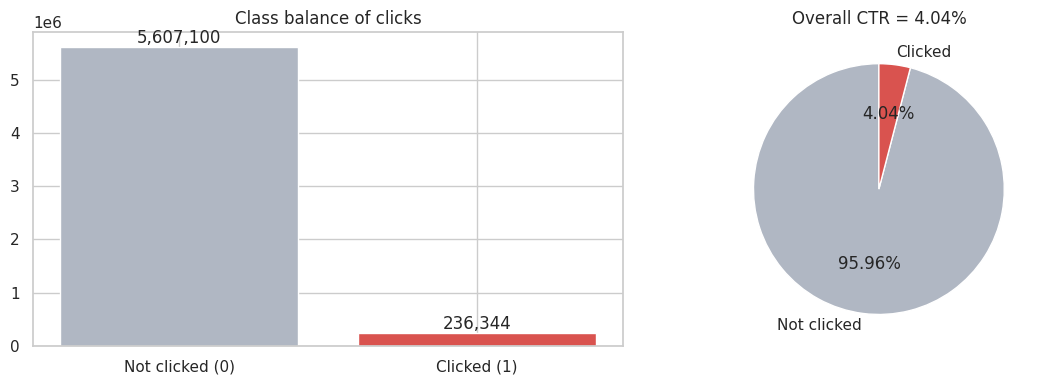

Heavy class imbalance (~4% positives) — shapes all downstream modelling: prefer class weights / resampling and AUC or PR metrics over accuracy.


In [10]:
# ===== 2. CLASS BALANCE OF CLICKS (target variable) =====
ctr = df["clicked"].mean()
counts = df["clicked"].value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(["Not clicked (0)", "Clicked (1)"], counts.values,
          color=["#b0b7c3", "#d9534f"])
ax[0].set_title("Class balance of clicks")
for i, v in enumerate(counts.values):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom")

ax[1].pie([1-ctr, ctr], labels=["Not clicked", "Clicked"],
          autopct="%1.2f%%", colors=["#b0b7c3", "#d9534f"], startangle=90)
ax[1].set_title(f"Overall CTR = {ctr:.2%}")
plt.tight_layout(); plt.show()

print("Heavy class imbalance (~4% positives) — shapes all downstream modelling: "
      "prefer class weights / resampling and AUC or PR metrics over accuracy.")

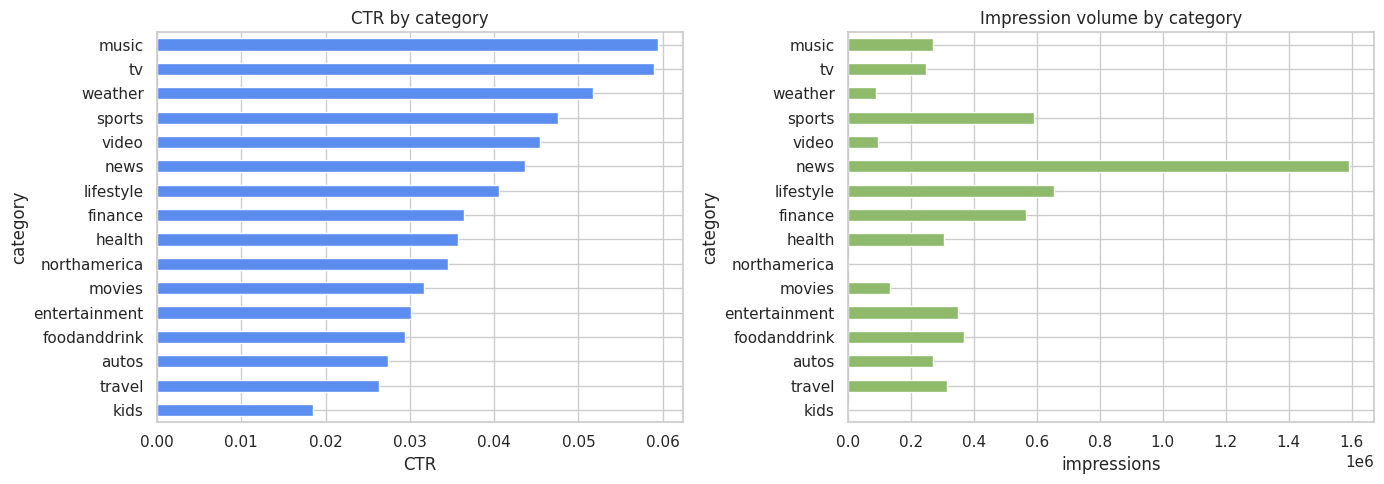

,impressions,clicks,ctr
category,,,
music,"269,008","15,988",5.94%
tv,"246,462","14,544",5.90%
weather,"88,646","4,582",5.17%
sports,"592,226","28,181",4.76%
video,"93,744","4,262",4.55%
news,"1,591,038","69,408",4.36%
lifestyle,"655,440","26,584",4.06%
finance,"564,671","20,597",3.65%
health,"304,088","10,863",3.57%


In [11]:
# ===== 3. CTR & VOLUME BY CATEGORY =====
cat = (df.groupby("category")
         .agg(impressions=("clicked", "size"), clicks=("clicked", "sum"))
         .assign(ctr=lambda d: d["clicks"] / d["impressions"])
         .sort_values("ctr", ascending=False))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
cat["ctr"].plot(kind="barh", ax=ax[0], color="#5b8def")
ax[0].set_title("CTR by category"); ax[0].set_xlabel("CTR"); ax[0].invert_yaxis()
cat["impressions"].plot(kind="barh", ax=ax[1], color="#8fb96b")
ax[1].set_title("Impression volume by category"); ax[1].set_xlabel("impressions")
ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

display(cat.style.format({"impressions":"{:,}","clicks":"{:,}","ctr":"{:.2%}"}))

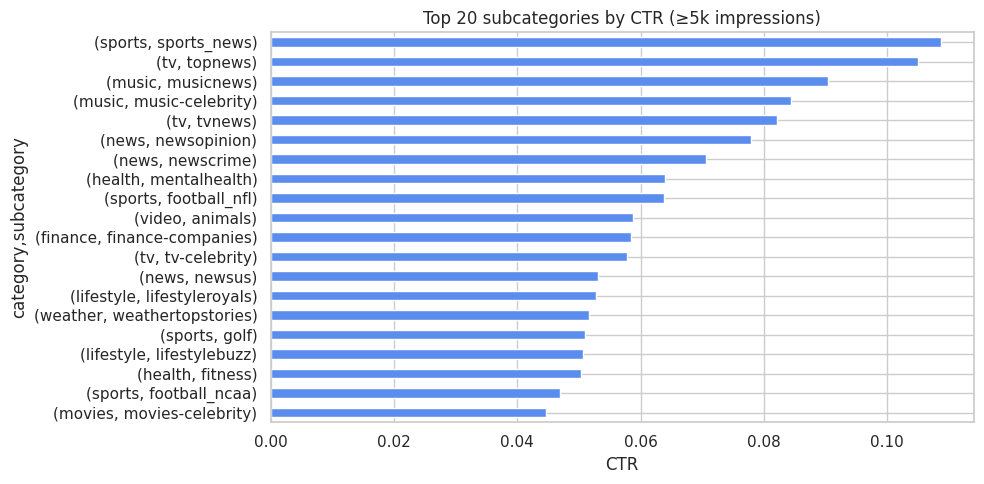

In [12]:
# ===== 4. TOP SUBCATEGORIES BY CTR (volume-filtered) =====
sub = (df.groupby(["category", "subcategory"])
         .agg(impressions=("clicked", "size"), clicks=("clicked", "sum"))
         .assign(ctr=lambda d: d["clicks"] / d["impressions"])
         .query("impressions >= 5000")
         .sort_values("ctr", ascending=False)
         .head(20))

sub["ctr"].plot(kind="barh", color="#5b8def",
                title="Top 20 subcategories by CTR (≥5k impressions)")
plt.gca().invert_yaxis(); plt.xlabel("CTR"); plt.tight_layout(); plt.show()
display(sub.style.format({"impressions":"{:,}","clicks":"{:,}","ctr":"{:.2%}"}))

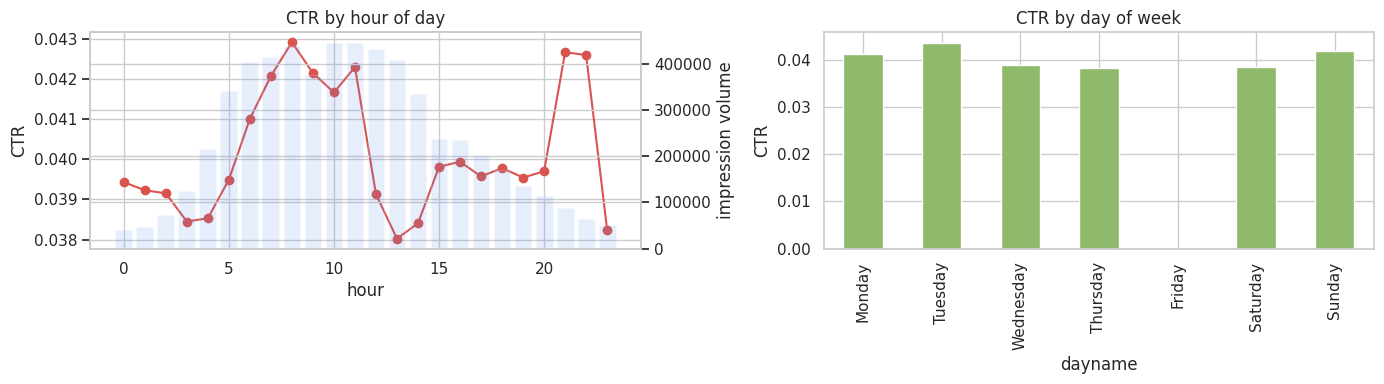

In [13]:
# ===== 5. TEMPORAL PATTERNS =====
df["hour"] = df["time"].dt.hour
df["dayname"] = df["time"].dt.day_name()
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

hourly = df.groupby("hour")["clicked"].agg(["size", "mean"])
daily = df.groupby("dayname")["clicked"].mean().reindex(day_order)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(hourly.index, hourly["mean"], marker="o", color="#d9534f")
ax[0].set_title("CTR by hour of day"); ax[0].set_xlabel("hour"); ax[0].set_ylabel("CTR")
ax2 = ax[0].twinx()
ax2.bar(hourly.index, hourly["size"], alpha=0.15, color="#5b8def")
ax2.set_ylabel("impression volume")
daily.plot(kind="bar", ax=ax[1], color="#8fb96b")
ax[1].set_title("CTR by day of week"); ax[1].set_ylabel("CTR")
plt.tight_layout(); plt.show()

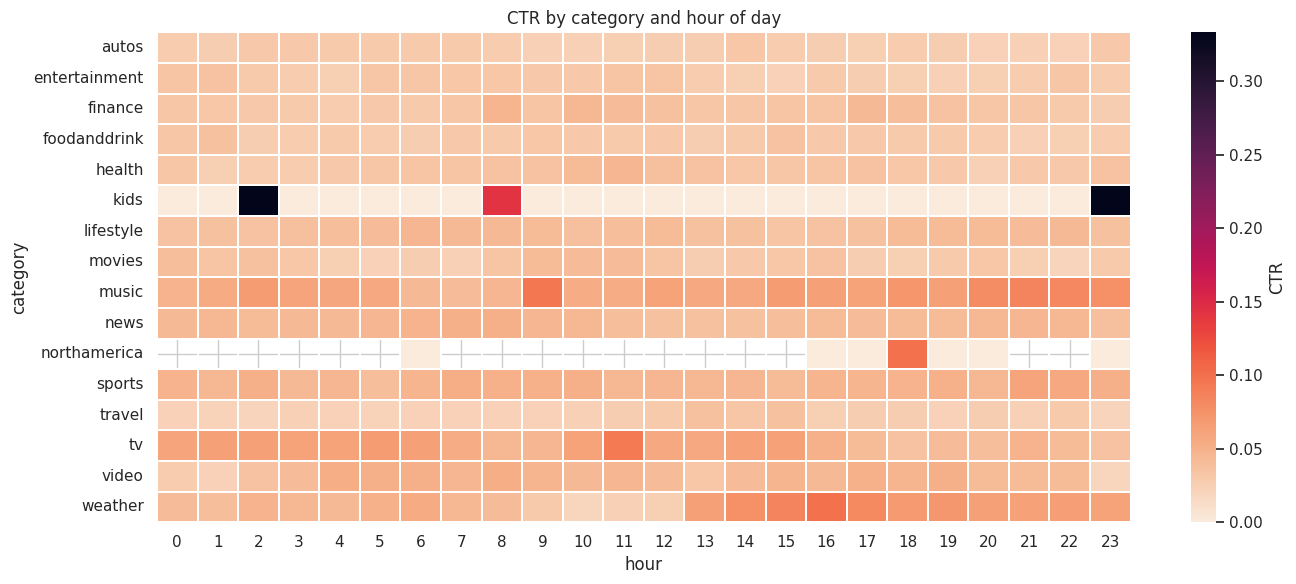

In [14]:
# ===== 6. CATEGORY x HOUR CTR HEATMAP (interaction effects) =====
pivot = df.pivot_table(index="category", columns="hour",
                       values="clicked", aggfunc="mean")
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap="rocket_r", linewidths=.3, cbar_kws={"label": "CTR"})
plt.title("CTR by category and hour of day")
plt.tight_layout(); plt.show()

       impressions     clicks        ctr
count    50000.000  50000.000  50000.000
mean       116.869      4.727      0.085
std        145.810      5.768      0.105
min          2.000      1.000      0.003
25%         25.000      1.000      0.029
50%         67.000      3.000      0.049
75%        152.000      6.000      0.091
max       1960.000    129.000      0.667


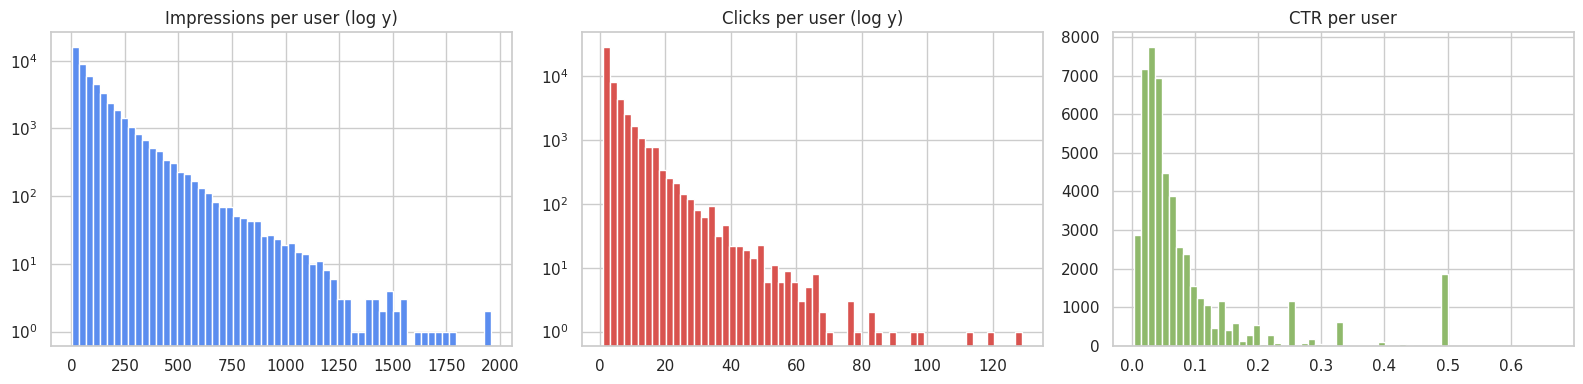

Users with zero clicks: 0.0%


In [15]:
# ===== 7. USER-LEVEL BEHAVIOUR (segmentation setup) =====
user = (df.groupby("user_id")
          .agg(impressions=("clicked", "size"), clicks=("clicked", "sum"))
          .assign(ctr=lambda d: d["clicks"] / d["impressions"]))
print(user.describe().round(3))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(user["impressions"], bins=60, color="#5b8def"); ax[0].set_yscale("log")
ax[0].set_title("Impressions per user (log y)")
ax[1].hist(user["clicks"], bins=60, color="#d9534f"); ax[1].set_yscale("log")
ax[1].set_title("Clicks per user (log y)")
ax[2].hist(user["ctr"], bins=60, color="#8fb96b")
ax[2].set_title("CTR per user")
plt.tight_layout(); plt.show()
print(f"Users with zero clicks: {(user['clicks']==0).mean():.1%}")

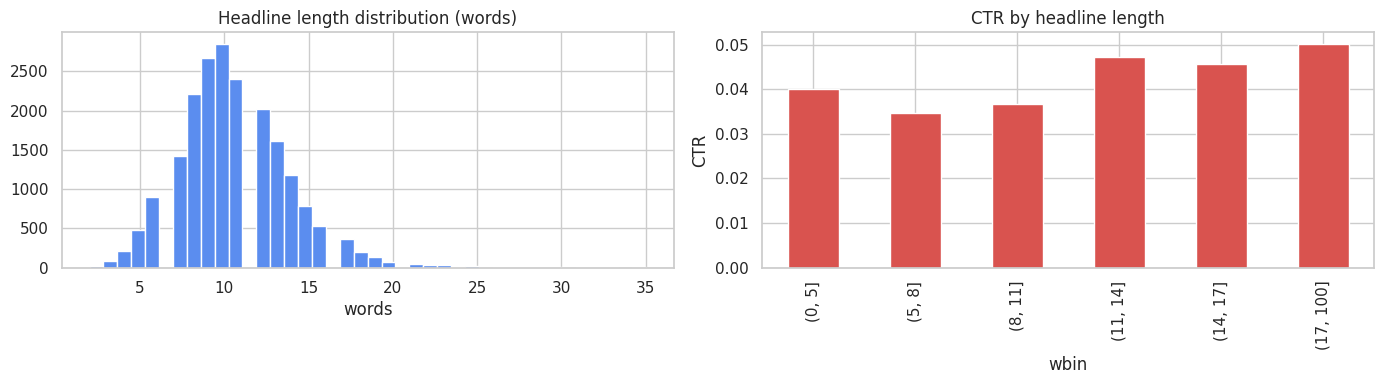

,impressions,ctr
wbin,,
"(0, 5]","213,079",4.01%
"(5, 8]","1,191,863",3.46%
"(8, 11]","2,193,866",3.68%
"(11, 14]","1,420,887",4.72%
"(14, 17]","585,247",4.57%
"(17, 100]","238,502",5.03%


In [16]:
# ===== 8. HEADLINE LENGTH vs CTR =====
df["title_words"] = df["title"].str.split().str.len()
bins = [0, 5, 8, 11, 14, 17, 100]
df["wbin"] = pd.cut(df["title_words"], bins)
len_ctr = (df.groupby("wbin", observed=True)["clicked"]
             .agg(impressions="size", ctr="mean"))

titles = df.drop_duplicates("news_id")[["title_words"]]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(titles["title_words"].dropna(), bins=40, color="#5b8def")
ax[0].set_title("Headline length distribution (words)"); ax[0].set_xlabel("words")
len_ctr["ctr"].plot(kind="bar", ax=ax[1], color="#d9534f")
ax[1].set_title("CTR by headline length"); ax[1].set_ylabel("CTR")
plt.tight_layout(); plt.show()
display(len_ctr.style.format({"impressions":"{:,}","ctr":"{:.2%}"}))

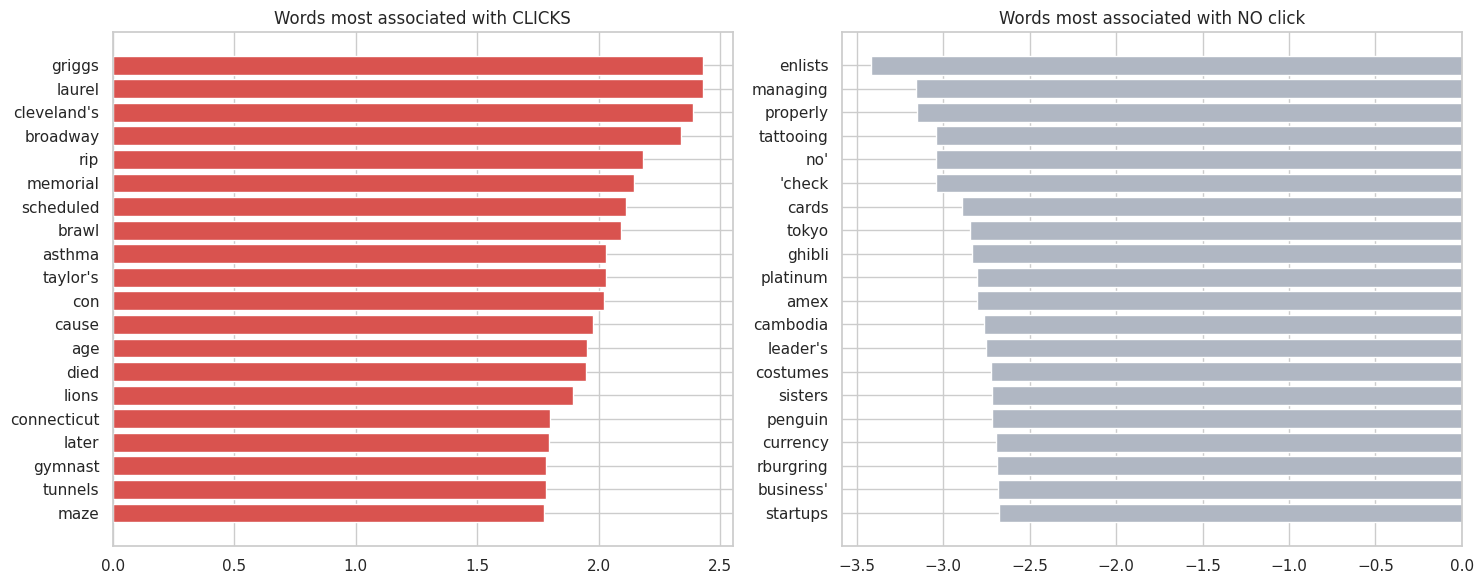

In [17]:
# ===== 9. HEADLINE KEYWORDS: clicked vs not (log-odds) =====
STOP = set("""the a an and or but of to in on for with at by from as is are was
were be been this that these those it its his her their our your my you we they
he she them how what why when who will would can could has have had not no new
say says said after over into out off up down""".split())

def tokens(s):
    return [w for w in re.findall(r"[a-z']+", str(s).lower())
            if w not in STOP and len(w) > 2]

clicked_w, unclicked_w = Counter(), Counter()
for t, c in zip(df["title"], df["clicked"]):
    (clicked_w if c == 1 else unclicked_w).update(tokens(t))

# log-odds with smoothing: which words tilt toward clicks
vocab = {w for w, n in (clicked_w + unclicked_w).items() if n >= 200}
tot_c, tot_u = sum(clicked_w.values()), sum(unclicked_w.values())
rows = []
for w in vocab:
    pc = (clicked_w[w] + 1) / (tot_c + len(vocab))
    pu = (unclicked_w[w] + 1) / (tot_u + len(vocab))
    rows.append((w, np.log(pc / pu), clicked_w[w], unclicked_w[w]))
lo = pd.DataFrame(rows, columns=["word", "log_odds", "in_clicked", "in_unclicked"])

top_click = lo.sort_values("log_odds", ascending=False).head(20)
top_noclick = lo.sort_values("log_odds").head(20)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax[0].barh(top_click["word"], top_click["log_odds"], color="#d9534f")
ax[0].set_title("Words most associated with CLICKS"); ax[0].invert_yaxis()
ax[1].barh(top_noclick["word"], top_noclick["log_odds"], color="#b0b7c3")
ax[1].set_title("Words most associated with NO click"); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()